## color embedding

### color from matplotlib

In [18]:
%matplotlib inline
# for Jupyter Notebook, to display plots inline

# a global variable to show the plotly figure interactively in Jupyter Notebook or statically as an image in github
SHOW_STATIC_IMG = True

def show_image(fig):
    from IPython.display import Image
    if SHOW_STATIC_IMG:
        return Image(fig.to_image(format="png"))
    else:
        return fig.show()

In [2]:
import matplotlib.colors as mcolors

# mcolors.CSS4_COLORS 是一個字典，直接包含了 CSS4 顏色名稱和它們的十六進制值
# 它的格式就是 {"color_name": "#RRGGBB"}
css4_colors = mcolors.CSS4_COLORS
css4_colors_set = set(css4_colors.values())
print(f"Total CSS4 colors: {len(css4_colors)}")
print(f"Number of unique colors in CSS4: {len(css4_colors_set)}")

Total CSS4 colors: 148
Number of unique colors in CSS4: 139


In [3]:
color_rbg_dict = dict()
color_name_dict = dict()

for name, rgb in mcolors.CSS4_COLORS.items():
    if rgb in color_rbg_dict:
        print(f"Duplicate RGB value found: {rgb} for color {name}, already mapped to {color_rbg_dict[rgb]}")
    else:
        color_rbg_dict[rgb] = name
        color_name_dict[name] = rgb

Duplicate RGB value found: #00FFFF for color cyan, already mapped to aqua
Duplicate RGB value found: #A9A9A9 for color darkgrey, already mapped to darkgray
Duplicate RGB value found: #2F4F4F for color darkslategrey, already mapped to darkslategray
Duplicate RGB value found: #696969 for color dimgrey, already mapped to dimgray
Duplicate RGB value found: #808080 for color grey, already mapped to gray
Duplicate RGB value found: #D3D3D3 for color lightgrey, already mapped to lightgray
Duplicate RGB value found: #778899 for color lightslategrey, already mapped to lightslategray
Duplicate RGB value found: #FF00FF for color magenta, already mapped to fuchsia
Duplicate RGB value found: #708090 for color slategrey, already mapped to slategray


In [4]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4)) 

In [5]:
color_name = 'red'
hex_to_rgb(color_name_dict[color_name])

(255, 0, 0)

### rgb vectors

In [7]:
import plotly.graph_objects as go
import matplotlib.colors as mcolors # 仍然使用 matplotlib 來獲取命名顏色列表

def plot_colors_in_rgb_3d_plotly(annotate_some_colors: bool = True):
    """
    使用 Plotly 繪製 3D 圖，將 Matplotlib 預定義的顏色名稱依照其 RGB 值定位，
    並以該顏色本身作為點的顏色。提供交互式功能。

    Args:
        annotate_some_colors (bool): 是否在圖上標註一些代表性的顏色名稱。
                                     如果顏色過多，標註可能會使圖表混亂。
    """
    # 1. 獲取顏色名稱和十六進制值
    # mcolors.CSS4_COLORS 提供了最全面的命名顏色列表
    named_colors = mcolors.CSS4_COLORS

    # 準備數據列表
    r_coords = []
    g_coords = []
    b_coords = []
    point_colors = [] # 用於 scatter 的顏色列表，可以是十六進制字符串
    color_names = []  # 用於 hovertext

    # 2. 遍歷所有顏色，提取 RGB 值
    for name, hex_value in named_colors.items():
        # mcolors.hex2color 將十六進制轉換為 RGB 浮點數 (0.0-1.0)
        # 我們需要將其轉換為 0-255 的整數，作為 3D 座標
        rgb_float = mcolors.hex2color(hex_value)
        r, g, b = [int(c * 255) for c in rgb_float]

        r_coords.append(r)
        g_coords.append(g)
        b_coords.append(b)
        point_colors.append(hex_value) # Plotly 可以直接使用十六進制字符串作為點的顏色
        color_names.append(name)

    # 3. 創建 Plotly 圖
    fig = go.Figure()

    # 4. 添加主散點圖 trace
    fig.add_trace(go.Scatter3d(
        x=r_coords,
        y=g_coords,
        z=b_coords,
        mode='markers', # 顯示為點
        marker=dict(
            size=5,
            color=point_colors, # 點的顏色直接使用十六進制值
            opacity=0.8
        ),
        hoverinfo='text', # 鼠標懸停時顯示自定義的文本
        hovertext=[f"名稱: {name}<br>十六進制: {hex_value}<br>RGB: ({r},{g},{b})"
                   for name, hex_value, r, g, b in zip(color_names, point_colors, r_coords, g_coords, b_coords)],
        name='所有命名顏色' # 用於圖例
    ))

    # 5. 設置佈局
    fig.update_layout(
        title='Matplotlib 命名顏色在 3D RGB 空間中的分佈 (Plotly 交互式)',
        scene=dict(
            xaxis_title='紅色 (R)',
            yaxis_title='綠色 (G)',
            zaxis_title='藍色 (B)',
            xaxis=dict(range=[0, 255], nticks=6), # 設置軸的範圍和刻度數量
            yaxis=dict(range=[0, 255], nticks=6),
            zaxis=dict(range=[0, 255], nticks=6),
            aspectmode='cube' # 確保軸的比例一致，視覺上更準確地呈現立方體
        ),
        margin=dict(l=0, r=0, b=0, t=40), # 調整邊距
        hovermode='closest' # 鼠標懸停時顯示最近點的信息
    )

    # 6. 添加選定的顏色名稱標註
    if annotate_some_colors:
        annotations_r = []
        annotations_g = []
        annotations_b = []
        annotation_texts = []

        # 選擇一些代表性的顏色進行標註，避免圖表過於擁擠
        colors_to_annotate = [
            'red', 'green', 'blue', 'white', 'black', 'yellow', 'cyan', 'magenta',
            'orange', 'purple', 'gray', 'darkred', 'lightgreen', 'skyblue', 'gold'
        ]
        
        # 確保只標註實際存在於 CSS4_COLORS 中的顏色
        colors_to_annotate = [c for c in colors_to_annotate if c in named_colors]

        # 創建一個字典，用於快速查找 RGB 座標
        name_to_rgb_coords = {name: [int(c * 255) for c in mcolors.hex2color(hex_value)]
                              for name, hex_value in named_colors.items()}

        for color_name in colors_to_annotate:
            r, g, b = name_to_rgb_coords[color_name]
            annotations_r.append(r)
            annotations_g.append(g)
            annotations_b.append(b)
            annotation_texts.append(color_name)

        if annotations_r: # 只有當有顏色需要標註時才添加 trace
            fig.add_trace(go.Scatter3d(
                x=annotations_r,
                y=annotations_g,
                z=annotations_b,
                mode='text', # 顯示為文字
                text=annotation_texts,
                textfont=dict(
                    color='black', # 文本顏色，通常選用對比色以確保可讀性
                    size=10
                ),
                hoverinfo='text',
                hovertext=[f"標註: {txt}" for txt in annotation_texts],
                name='標註顏色名稱' # 用於圖例
            ))

    # 7. 顯示圖表
    return fig


fig = plot_colors_in_rgb_3d_plotly(annotate_some_colors=True)

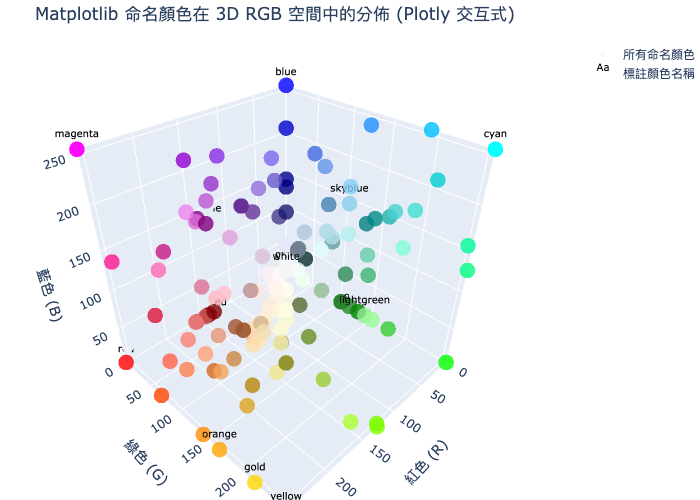

In [19]:
show_image(fig)

### Language model embedding


In [23]:
from sentence_transformers import SentenceTransformer, util
import numpy as np

def get_sentence_embeddings(sentences: list[str], model_name: str = 'all-MiniLM-L6-v2'):
    """
    使用 Sentence Transformers 模型生成句子嵌入。

    Args:
        sentences (list[str]): 要生成嵌入的句子列表。
        model_name (str): 要使用的預訓練模型名稱。
                          'all-MiniLM-L6-v2' 是一個小巧但性能不錯的通用模型。
                          其他選項如 'paraphrase-multilingual-MiniLM-L12-v2' (多語言),
                          'all-mpnet-base-v2' (性能更強) 等。

    Returns:
        np.ndarray: 句子的嵌入向量矩陣。
    """
    print(f"正在載入 Sentence Transformer 模型: {model_name}...")
    model = SentenceTransformer(model_name)
    print("模型載入完成。")

    print("正在生成句子嵌入...")
    embeddings = model.encode(sentences, convert_to_numpy=True)
    print(f"生成 {len(sentences)} 個句子的嵌入，每個嵌入維度為 {embeddings.shape[1]}。")
    return embeddings

def plot_color_name_embeddings_3d_plotly_st(
    color_names: list[str],
    color_hex_values: list[str],
    color_rgb_values: list[tuple[int, int, int]],
    embeddings_3d: np.ndarray
):
    """
    使用 Plotly 繪製 3D 顏色名稱的 Sentence Transformer 嵌入。
    """
    import plotly.graph_objects as go

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=embeddings_3d[:, 0],
        y=embeddings_3d[:, 1],
        z=embeddings_3d[:, 2],
        mode='markers',
        marker=dict(
            size=6,
            color=color_hex_values,
            opacity=0.8
        ),
        hoverinfo='text',
        hovertext=[f"名稱: {name}<br>十六進制: {hex_val}<br>RGB: {rgb_val}"
                   for name, hex_val, rgb_val in zip(color_names, color_hex_values, color_rgb_values)],
        name='顏色名稱嵌入'
    ))

    # 標註一些代表性的顏色名稱 (與之前相同，但使用新的嵌入座標)
    # 這裡為了簡潔，省略了具體的標註邏輯，您可以根據需要添加
    # 確保 `color_names` 和 `embeddings_3d` 的順序一致

    fig.update_layout(
        title='顏色名稱 Sentence Transformer 嵌入在 3D 向量空間中的分佈 (Plotly)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        hovermode='closest'
    )
    return fig

In [24]:
import umap
import matplotlib.colors as mcolors

# 獲取顏色名稱和相關
named_colors = mcolors.CSS4_COLORS
color_names_list = list(named_colors.keys())
color_hex_values_list = list(named_colors.values())
color_rgb_values_list = [tuple(int(c * 255) for c in mcolors.hex2color(h)) for h in color_hex_values_list]

# 使用 Sentence Transformers 生成嵌入
# 注意：Sentence Transformers 模型通常對多詞短語處理得很好
embeddings = get_sentence_embeddings(color_names_list)

print("正在執行 UMAP 降維...")
reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
embeddings_3d = reducer.fit_transform(embeddings)
print(f"UMAP 降維後維度: {embeddings_3d.shape[1]}")

# 繪製 3D 圖
emb_fig = plot_color_name_embeddings_3d_plotly_st(
    color_names_list,
    color_hex_values_list,
    color_rgb_values_list,
    embeddings_3d
)

正在載入 Sentence Transformer 模型: all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9076.29it/s]


模型載入完成。
正在生成句子嵌入...
生成 148 個句子的嵌入，每個嵌入維度為 384。
正在執行 UMAP 降維...


/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 降維後維度: 3


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


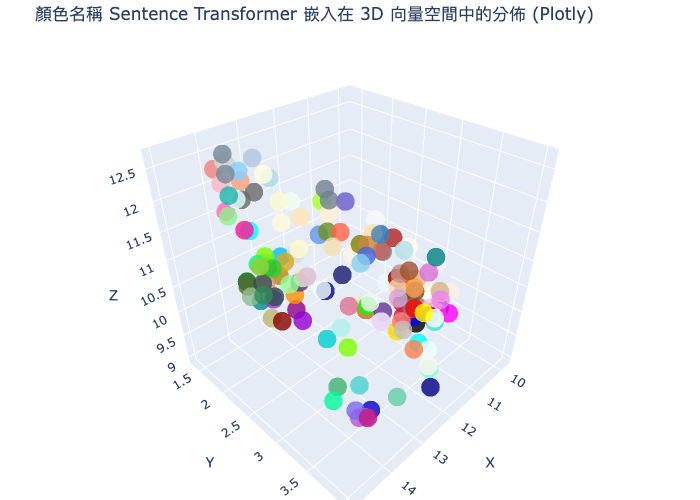

In [25]:
show_image(emb_fig)